<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/DSR_44_Autoregression_buildGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import glob
import random
import shutil
import tensorflow as tf
from tensorflow.keras import preprocessing
from tensorflow.keras import models, layers
from tqdm import tqdm

In [3]:
# Where the text files are going to live.
dataset_path = "dataset"
dataset_path_all = os.path.join(dataset_path, "all")
dataset_path_train = os.path.join(dataset_path, "train")
dataset_path_valid = os.path.join(dataset_path, "valid")

# Just use 20 files.
file_number = 20

# Gather the corpus if it has not been gathered yet.
if not os.path.exists(dataset_path):

    # Create all the folders.
    for path in [dataset_path, dataset_path_all, dataset_path_train, dataset_path_valid]:
        if not os.path.exists(path):
            os.mkdir(path)

    # Clone the repo.
    !git clone https://github.com/vilmibm/lovecraftcorpus

    # Find all the files.
    paths_all = glob.glob("lovecraftcorpus/*.txt")
    print(sorted(paths_all))

    # Standardize.
    for path in paths_all:
        content = open(path).read()
        content = content.lower()
        for punctuation in ".,:;?!":
            content = content.replace(punctuation, " " + punctuation)
        open(path, "w").write(content)

    # Do not use all.
    paths_all = paths_all[:file_number]

    # Split 80/20.
    split_index = int(len(paths_all) * 0.8)
    paths_train = paths_all[:split_index]
    paths_valid = paths_all[split_index:]

    # Copy files.
    def copy(paths, destination):
        for path in paths:
            shutil.copy2(path, destination)
    copy(paths_all, dataset_path_all)
    copy(paths_train, dataset_path_train)
    copy(paths_valid, dataset_path_valid)

    # Delete repo.
    !rm -rf lovecraftcorpus

    # Done.
    print("Corpus downloaded.")

Cloning into 'lovecraftcorpus'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 74 (delta 0), reused 3 (delta 0), pack-reused 70 (from 1)
Receiving objects: 100% (74/74), 1.12 MiB | 23.40 MiB/s, done.
['lovecraftcorpus/alchemist.txt', 'lovecraftcorpus/arthur_jermyn.txt', 'lovecraftcorpus/azathoth.txt', 'lovecraftcorpus/beast.txt', 'lovecraftcorpus/beyond_wall_of_sleep.txt', 'lovecraftcorpus/book.txt', 'lovecraftcorpus/celephais.txt', 'lovecraftcorpus/charles_dexter_ward.txt', 'lovecraftcorpus/clergyman.txt', 'lovecraftcorpus/colour_out_of_space.txt', 'lovecraftcorpus/cool_air.txt', 'lovecraftcorpus/crawling_chaos.txt', 'lovecraftcorpus/cthulhu.txt', 'lovecraftcorpus/dagon.txt', 'lovecraftcorpus/descendent.txt', 'lovecraftcorpus/doorstep.txt', 'lovecraftcorpus/dreams_in_the_witch.txt', 'lovecraftcorpus/dunwich.txt', 'lovecraftcorpus/erich_zann.txt', 'lovecraftcorpus/ex_oblivione.txt', 'love

In [4]:
batch_size = 32 # NOT FOR SGD
# seed = 42

def create_dataset(dataset_path):
    dataset = preprocessing.text_dataset_from_directory(
        dataset_path,
        labels=None,
        batch_size=batch_size,
        # seed=seed
    )
    return dataset

dataset_original_all = create_dataset(dataset_path_all)
dataset_original_train = create_dataset(dataset_path_train)
dataset_original_valid = create_dataset(dataset_path_valid)

Found 20 files.
Found 16 files.
Found 4 files.


In [5]:
for books in dataset_original_all:
    for book in books:
        print(book)

tf.Tensor(b'dreams in the witch-house\n\nwhether the dreams brought on the fever or the fever brought on the dreams walter gilman did not know . behind everything crouched the brooding , festering horror of the ancient town , and of the mouldy , unhallowed garret gable where he wrote and studied and wrestled with figures and formulae when he was not tossing on the meagre iron bed . his ears were growing sensitive to a preternatural and intolerable degree , and he had long ago stopped the cheap mantel clock whose ticking had come to seem like a thunder of artillery . at night the subtle stirring of the black city outside , the sinister scurrying of rats in the wormy partitions , and the creaking of hidden timbers in the centuried house , were enough to give him a sense of strident pandemonium . the darkness always teemed with unexplained sound--and yet he sometimes shook with fear lest the noises he heard should subside and allow him to hear certain other fainter noises which he suspect

In [6]:
vocabulary_size = 10_000

encoder = layers.TextVectorization(
    max_tokens=vocabulary_size,
    standardize=None,
    split="whitespace",
    output_mode="int"
)
encoder.adapt(dataset_original_all)

In [7]:
vocabulary = encoder.get_vocabulary()
print([str(word) for word in vocabulary])

['', '[UNK]', 'the', ',', 'of', '.', 'and', 'to', 'a', 'in', 'i', 'was', 'that', 'had', 'it', 'he', 'as', 'with', 'at', 'were', 'from', 'for', 'on', 'which', 'but', 'his', 'my', 'not', ';', 'we', 'all', 'by', 'or', 'be', 'this', 'could', 'have', 'they', 'there', 'me', 'some', 'been', 'an', 'one', 'when', 'their', 'no', 'what', 'so', 'would', 'its', 'him', 'more', 'about', 'our', 'out', 'old', 'is', 'up', 'into', 'them', 'now', 'great', 'seemed', 'though', 'only', 'through', 'than', 'saw', 'those', 'any', 'did', 'very', 'time', 'before', 'other', 'then', 'even', 'must', 'after', 'these', 'like', 'over', 'down', 'if', 'where', 'things', 'who', 'found', 'such', 'place', 'came', 'thing', 'city', 'made', 'strange', 'certain', '?', 'whose', 'thought', 'much', 'her', 'might', 'us', 'man', 'most', 'first', 'long', 'beyond', 'stone', 'too', 'world', 'upon', 'never', 'knew', 'still', 'something', 'once', 'many', 'back', 'night', 'men', 'again', 'you', 'years', 'two', 'black', 'see', 'come', 'tol

In [8]:
sequence_length = 32
padding_token_id = 0

def create_dataset_for_autoregression(dataset, hop_length=1):
    x_inputs = []
    y_outputs = []

    for books in dataset:
        books = encoder(books).numpy()

        for book in tqdm(books):

            # Tokenized book for padding.
            book = [int(index) for index in list(book) if index != padding_token_id] # Word indices space

            for start_index in range(0, len(book) - sequence_length, hop_length):
                x = book[start_index:start_index + sequence_length]
                y = book[start_index +1:start_index + sequence_length + 1]
                assert len(x) == sequence_length
                assert len(y) == sequence_length
                x_inputs += [x]
                y_outputs += [y]

    # Done.
    return tf.data.Dataset.from_tensor_slices((x_inputs, y_outputs))

dataset_train = create_dataset_for_autoregression(dataset_original_train)
dataset_valid = create_dataset_for_autoregression(dataset_original_valid)
print("Done.")

100%|██████████| 4/4 [00:00<00:00, 59.57it/s]


Done.


In [9]:
def decode(indices):
    return " ".join([vocabulary[index] for index in indices if vocabulary[index] != ""])

for input, output  in dataset_train.take(10):
    print("input: ", " ".join([str(x) for x in input.numpy()]))
    print("output:", output.numpy())
    print("input decoded: ", decode(input))
    print("output decoded:", decode(output))
    print("")

input:  2 437 9 2 136 105 395 4 30 3454 130 2 175 6371 1197 490 692 20 2944 1273 3 3367 3434 112 40 1546 5704 861 32 3113 232 40
output: [ 437    9    2  136  105  395    4   30 3454  130    2  175 6371 1197
  490  692   20 2944 1273    3 3367 3434  112   40 1546 5704  861   32
 3113  232   40  877]
input decoded:  the picture in the house most horrible of all sights are the little unpainted wooden houses remote from travelled ways , usually squatted upon some damp grassy slope or leaning against some
output decoded: picture in the house most horrible of all sights are the little unpainted wooden houses remote from travelled ways , usually squatted upon some damp grassy slope or leaning against some gigantic

input:  437 9 2 136 105 395 4 30 3454 130 2 175 6371 1197 490 692 20 2944 1273 3 3367 3434 112 40 1546 5704 861 32 3113 232 40 877
output: [   9    2  136  105  395    4   30 3454  130    2  175 6371 1197  490
  692   20 2944 1273    3 3367 3434  112   40 1546 5704  861   32 3113


In [10]:
import matplotlib.pyplot as plt

def render_history(history):
    plt.title("Training loss vs. validation loss")
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.legend()
    plt.show()
    plt.close()

    plt.title("Training accuracy vs. validation accuracy")
    plt.plot(history.history["accuracy"], label="accuracy")
    plt.plot(history.history["val_accuracy"], label="val_accuracy")
    plt.legend()
    plt.show()
    plt.close()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 32, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32, 10000)      │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701,584 (10.31 MB)

 Trainable params: 2,701,584 (10.31 MB)

 Non-trainable params: 0 (0.00 B)

Compiling model...
Training model...
Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 92s 576ms/step - accuracy: 0.0588 - loss: 7.5637 - val_accuracy: 0.0675 - val_loss: 6.8134
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 85s 567ms/step - accuracy: 0.0629 - loss: 6.5576 - val_accuracy: 0.0675 - val_loss: 6.7769
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 562ms/step - accuracy: 0.0771 - loss: 6.4393 - val_accuracy: 0.1040 - val_loss: 6.5414
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 563ms/step - accuracy: 0.1065 - loss: 6.2101 - val_accuracy: 0.1085 - val_loss: 6.4078
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 562ms/step - accuracy: 0.1181 - loss: 6.0071 - val_accuracy: 0.1330 - val_loss: 6.3311
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 142s 563ms/step - accuracy: 0.1399 - loss: 5.8520 - val_accuracy: 0.1362 - val_loss: 6.2921
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 562ms/step - accuracy: 0.1506 - loss: 5.7264 - val_accuracy: 0.1440 - val_loss: 6.2730
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 5

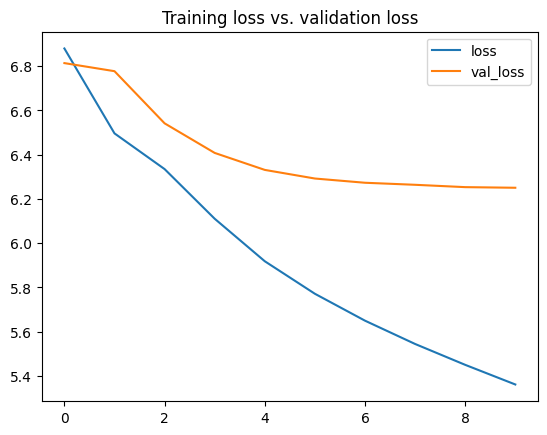

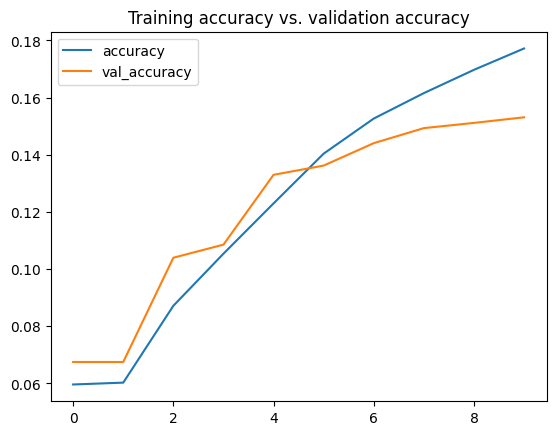

In [18]:
embedding_size = 128

model = models.Sequential()
model.add(layers.Embedding(vocabulary_size, embedding_size, input_length=sequence_length))
model.add(layers.LSTM(embedding_size, return_sequences=True))
model.add(layers.Dense(vocabulary_size, activation="softmax"))
model.build(input_shape=(None, sequence_length))
model.summary()

# Compiling the model.
print("Compiling model...")
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Training the model.
print("Training model...")
history = model.fit(
    dataset_train.cache().shuffle(10_000).batch(1024),
    validation_data=dataset_valid.cache().batch(1024),
    epochs=10
)

# Render the history.
render_history(history)